## Часть 2.

Современные виртуальные ассистенты &mdash; это сложные системы, состоящие на самом деле из большого количества моделей. Так, например, если мы говорим о голосовых ассистентах, то после запроса пользователя могут решаться следующие задачи:
* распознавание речи,
* предобработка текста,
* распознавание именованных сущностей, намерения пользователя,
* переход в другой навык (сервис), переключение на другую модель.

В этой задаче мы будем пытаться построить свою небольшую модель для распознавания намерения пользователя. Предположим, что в нашего бота Физтех.Статистики мы думаем добавить функциональности. Для каждого запроса на **естественном языке** мы хотим понять намерение пользователя, чтобы связать этот запрос с имеющимися сценариями. Например по запросам "когда дедлайны", "когда следующая лекция", "кому писать с вопросом по большой домашке" мы бы переключались на заготовленный сценарий взаимодействия без необходимости подключения преподавателя. Таким образом, наш роутинг запроса на самом деле сводится к задаче классификации текста, но с некоторыми особенностями. Обычно таких сервисов и сценариев много, при этом к уже имеющимся с течением времени добавляются новые. Возникает необходимость уметь быстро дообучать модель, добавляя новые классы, но и делать это так, чтобы качество для старых оставалось приемлемым.



![intent](https://f.hubspotusercontent20.net/hubfs/2734675/Intent-Classification-blog-images.jpg)

Будем работать с [данными](https://www.kaggle.com/datasets/constantinwerner/qa-intents-dataset-university-domain), которые собраны Новосибирским Государственным Университетом для своего QA-чатбота. Выбор в большой степени обусловлен именно "студенческим доменом". Описание гласит, что датасет содержит 142 интента (класса) и порядка 50-220 фраз на русском языке для каждого.

   0. Проведите небольшую аналитику имеющихся данных. Какой размер датасета? Сколько в среднем у нас имеется примеров на класс?  Что можно сказать насчет длины текстов, с которыми придется работать? С какими запросами приходится иметь дело?

   1. Для начала обучите какую-нибудь модель на основе архитектуры трансформер (например BERT-based модель для русского языка) целиком на исходном датасете. Не забудьте про валидацию. Измерьте качество на тестовой выборке. В качестве целевой метрики используйте точность.

   2. Далее попробуем имитировать следующий сетап. Предположим, что сначала у нас имеется 122 класса, к которым в течение времени планируется добавить еще 20 (а потом может быть еще). Выделите начальные 122 класса и обучите сначала модель на них. Посчитайте точность на тесте. Теперь, когда нам потребуется добавить новые интенты, нам бы не хотелось обучать модель заново, так как это может занять много времени, делать это придется довольно часто, а научиться поддерживать новые сценарии хотелось бы быстро. Мы поступим следующим образом:
       * Будем обучать только слой для классификации. При добавлении новых классов к нему добавляются лишь новые случайно инициализированные строки(столбцы), большой трансформер при этом остается замороженным.
       * Для еще большего ускорения процесса дообучения данные, которые соответствуют "первым" 122 классам можно предварительно пропустить через трансформер, а полученные скрытые состояния сохранить на диск. Таким образом, при появлении новых интентов и данных к ним через замороженный трансформер потребуется прогнать лишь новые тексты.
       * Проведите процесс дообучения на данных, соответствующим всем 142 классам, с учетом вышеизложенных предложений.
       * Сравните получившуюся модель на тестовой выборки с моделью из первого пункта.
    
4. Проведите **один** эксперимент, в котором вы можете:
    * Поэкспериментировать с разными головами для классификации (линейный слой, двухслойный MLP) и пуллингами (`[CLS]`, Mean-pooling).
    * Провести агументации запросов с использованием [augmentex](https://github.com/ai-forever/augmentex). Какие из агументаций наиболее полезны для нашего случая?

5. Сравните результаты с точки зрения значения целевой метрики, а также эффективности по времени обучения и дообучения для разных подходов. Какие плюсы и минусы описанного в втором пункте метода? Какие улучшения вы можете предложить? Попробуйте найти, например, релевантные статьи или блог-посты.

In [1]:
!pip install -U transformers --quiet
!pip install augmentex --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.5/22.5 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 68.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import random

import torch
import six
import torch.nn as nn
from torch.nn import CrossEntropyLoss

from torch.utils.data import Dataset, DataLoader
import transformers
from transformers import AutoTokenizer, BertForMaskedLM, DataCollatorForLanguageModeling
from transformers import DataCollatorWithPadding
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
from transformers.trainer_utils import EvalPrediction
from scipy.special import softmax

from sklearn.metrics import f1_score, accuracy_score

from tqdm.notebook import tqdm
import wandb
from kaggle_secrets import UserSecretsClient
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from torch.nn import DataParallel
from augmentex import WordAug, CharAug

import re
import gc
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

user_secrets = UserSecretsClient()
wandb_key = user_secrets.get_secret("wandb-key")

2025-05-07 16:08:35.467600: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746634115.928604      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746634116.051969      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
wandb.login(key=wandb_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: demoren (demoren_mipt) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
data_train = pd.read_csv("/kaggle/input/qa-intents-dataset-university-domain/dataset_train.tsv", sep='\t', names=["question", "class"])
data_val = pd.read_csv("/kaggle/input/qa-intents-dataset-university-domain/dataset_test.tsv", sep='\t', names=["question", "class"])

**0. Проведем анализ данных**

In [5]:
data_train.shape, data_val.shape

((13230, 2), (883, 2))

In [6]:
data_train

,question,class
0,мне нужна справка,statement_general
1,оформить справку,statement_general
2,взять справку,statement_general
3,справку как получить,statement_general
4,справку ммф где получаться,statement_general
...,...,...
13225,тупой,smalltalk_abuse
13226,робот бестолковый,smalltalk_abuse
13227,несообразительный,smalltalk_abuse
13228,ты бестолковый,smalltalk_abuse


In [7]:
# Подсчет количества примеров на каждый класс в train и val
train_class_counts = data_train['class'].value_counts()
val_class_counts = data_val['class'].value_counts()

# Среднее количество примеров на класс
average_train = train_class_counts.mean()
average_val = val_class_counts.mean()

print(f"Среднее количество примеров на класс (train): {average_train:.2f}")
print(f"Среднее количество примеров на класс (val): {average_val:.2f}")


Среднее количество примеров на класс (train): 93.17
Среднее количество примеров на класс (val): 6.26


Посчитаем длину текстов в символах

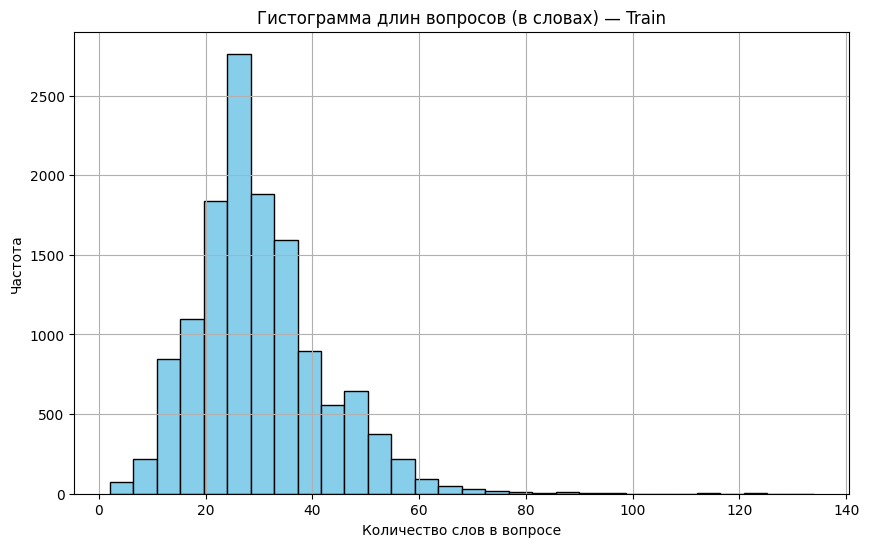

In [8]:
data_train['length_chars'] = data_train['question'].apply(lambda x: len(str(x)))

# Построение гистограммы
plt.figure(figsize=(10, 6))
plt.hist(data_train['length_chars'], bins=30, color='skyblue', edgecolor='black')
plt.title("Гистограмма длин вопросов (в словах) — Train")
plt.xlabel("Количество слов в вопросе")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

Посмотрим на виды запросов.

In [9]:
# Получение списка уникальных классов
unique_classes = data_train['class'].unique()

# Случайный выбор 4 классов
random_classes = random.sample(list(unique_classes), 4)

# Для каждого выбранного класса — вывод 2 случайных вопросов
for cls in random_classes:
    examples = data_train[data_train['class'] == cls]['question'].sample(2, random_state=42).tolist()
    print(f"\nКласс: {cls}")
    for i, q in enumerate(examples, 1):
        print(f"  Пример {i}: {q}")


Класс: cvvr_define
  Пример 1: центр по внеучебной и воспитательной работе находится
  Пример 2: цввр

Класс: highscholarship
  Пример 1: стипендия повышенная хотеть!
  Пример 2: стипендия повышенная получаться?

Класс: loc_nuclphysinstitute
  Пример 1: найти будкер
  Пример 2: будкер разыскать

Класс: loc_gym
  Пример 1: находится спортзал
  Пример 2: спортик отыскать


**1. Обучение первой модели**

Для начала закодируем классы.

In [10]:
le = LabelEncoder()

data_train['class_encoded'] = le.fit_transform(data_train['class'])
data_val['class_encoded'] = le.transform(data_val['class'])

In [11]:
tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased")

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [12]:
class IntentDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels":         torch.tensor(label, dtype=torch.long)
        }

In [13]:
train_dataset = IntentDataset(
    texts=data_train["question"].tolist(),
    labels=data_train["class_encoded"].tolist(),
    tokenizer=tokenizer
)

val_dataset = IntentDataset(
    texts=data_val["question"].tolist(),
    labels=data_val["class_encoded"].tolist(),
    tokenizer=tokenizer
)

In [14]:
num_labels = data_train['class_encoded'].nunique()

first_model = AutoModelForSequenceClassification.from_pretrained(
    "DeepPavlov/rubert-base-cased",
    num_labels=num_labels
)

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [16]:
is_development_mode = False

if is_development_mode:
    max_steps = 100  # Тренировка на одном батче
else:
    max_steps = -1  # Стандартный режим: все шаги

training_args = TrainingArguments(
    output_dir="./results",
    run_name="bert-baseline",
    eval_strategy="epoch",  # Оценка после каждой эпохи
    save_strategy="epoch",  # Сохранение модели после каждой эпохи
    logging_strategy="steps",
    logging_steps=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=128,
    num_train_epochs=10,
    learning_rate=2e-5,
    weight_decay=1e-3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="wandb",
    save_total_limit=2,
    dataloader_num_workers=4,
    fp16=True,
    local_rank=-1,
    max_steps=max_steps  # Ограничиваем количество шагов
)

In [17]:
wandb.init(
    project="nlp_part_2",   # имя проекта в W&B
    name="bert-rubert-baseline",       # название конкретного запуска
)

trainer = Trainer(
    model=first_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

# Оценка точности на валидационной выборке
eval_results = trainer.evaluate()
print(f"Accuracy on baseline: {eval_results['eval_accuracy']}")


wandb.finish()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Tracking run with wandb version 0.19.6
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250507_160917-aqqshoim
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run bert-rubert-baseline
wandb: ⭐️ View project at https://wandb.ai/demoren_mipt/nlp_part_2
wandb: 🚀 View run at https://wandb.ai/demoren_mipt/nlp_part_2/runs/aqqshoim
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,3.456700,3.233283,0.514156
2,2.337400,2.071532,0.711212
3,1.518200,1.375119,0.855040
4,1.075000,0.946747,0.904870
5,0.800100,0.688640,0.939977
6,0.609000,0.532519,0.947905
7,0.511800,0.440079,0.954700
8,0.439300,0.383658,0.953567
9,0.393500,0.353775,0.955832
10,0.413200,0.343881,0.954700


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked t

Accuracy on baseline: 0.9546998867497168


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁▄▆▇███████
wandb:               eval/loss █▅▃▂▂▁▁▁▁▁▁
wandb:            eval/runtime █▂▂▂▃▂▃▃▃▁▁
wandb: eval/samples_per_second ▁▆▇▇▆▇▆▆▆██
wandb:   eval/steps_per_second ▁▆▇▇▆▇▆▆▆██
wandb:             train/epoch ▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
wandb:       train/global_step ▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇███
wandb:         train/grad_norm █▆▆▅▅▅▅▄▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▃▃▂▁▂▂▁▁▁▁▃▁▁▁▁▁▂
wandb:     train/learning_rate █████▇▇▇▆▆▆▅▅▅▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
wandb:              train/loss ██▇▆▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:            eval/accuracy 0.9547
wandb:                eval/loss 0.34388
wandb:             eval/runtime 3.8731
wandb:  eval/samples_per_second 227.982
wandb:    eval/steps_per_second 1.033
wandb:               total_flos 8713337101056000.0
wandb:              train/epoch 10


In [18]:
del first_model
gc.collect()
torch.cuda.empty_cache()

**2. Случай, когда все классы неизвестны**

In [19]:
# Разделение на 122 класса
initial_classes = data_train['class'].unique()[:122]
data_train_122 = data_train[data_train['class'].isin(initial_classes)].copy()
data_val_122 = data_val[data_val['class'].isin(initial_classes)].copy()

# Кодирование классов для первых 122 классов
le_122 = LabelEncoder()
data_train_122['class_encoded'] = le_122.fit_transform(data_train_122['class'])
data_val_122['class_encoded'] = le_122.transform(data_val_122['class'])

In [20]:
train_dataset_122 = IntentDataset(
    texts=data_train_122["question"].tolist(),
    labels=data_train_122["class_encoded"].tolist(),
    tokenizer=tokenizer
)
val_dataset_122 = IntentDataset(
    texts=data_val_122["question"].tolist(),
    labels=data_val_122["class_encoded"].tolist(),
    tokenizer=tokenizer
)

In [21]:
# Обучение модели на 122 классах
num_labels_122 = len(initial_classes)
model_122 = AutoModelForSequenceClassification.from_pretrained(
    "DeepPavlov/rubert-base-cased",
    num_labels=num_labels_122
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
training_args_122 = TrainingArguments(
    output_dir="./results_122",
    run_name="bert-122-classes",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=128,
    num_train_epochs=10,
    learning_rate=2e-5,
    weight_decay=1e-3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="wandb",
    save_total_limit=2,
    dataloader_num_workers=4,
    fp16=True
)

In [23]:
wandb.init(project="nlp_part_2", name="bert-rubert-122-classes")
trainer_122 = Trainer(
    model=model_122,
    args=training_args_122,
    train_dataset=train_dataset_122,
    eval_dataset=val_dataset_122,
    compute_metrics=compute_metrics
)
trainer_122.train()

# Оценка точности на валидационной выборке
eval_results_122 = trainer_122.evaluate()
print(f"Accuracy on 122 classes: {eval_results_122['eval_accuracy']}")

# Сохранение модели
model_122.save_pretrained("./model_122")
tokenizer.save_pretrained("./model_122")

wandb.finish()

wandb: Tracking run with wandb version 0.19.6
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250507_163605-1mc58mod
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run bert-rubert-122-classes
wandb: ⭐️ View project at https://wandb.ai/demoren_mipt/nlp_part_2
wandb: 🚀 View run at https://wandb.ai/demoren_mipt/nlp_part_2/runs/1mc58mod
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,3.749200,3.444132,0.440608
2,2.398200,2.180058,0.726519
3,1.651200,1.438172,0.859116
4,1.114100,0.999588,0.914365
5,0.854700,0.741060,0.926796
6,0.699500,0.587877,0.935083
7,0.588600,0.489495,0.939227
8,0.499700,0.435503,0.946133
9,0.463300,0.403122,0.947514
10,0.452600,0.393018,0.947514


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked t

Accuracy on 122 classes: 0.9475138121546961


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁▅▇████████
wandb:               eval/loss █▅▃▂▂▁▁▁▁▁▁
wandb:            eval/runtime ▂▃▃▄█▃▂▅▄▂▁
wandb: eval/samples_per_second ▇▅▆▅▁▆▇▄▅▇█
wandb:   eval/steps_per_second ▇▅▆▅▁▅▇▄▅▇█
wandb:             train/epoch ▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
wandb:       train/global_step ▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇██
wandb:         train/grad_norm █▃▂▂▂▂▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▂▂▁▁▂▁▁▁▂▁▁▁▁▂▁▁▁▂▁
wandb:     train/learning_rate ██▇▇▇▇▇▇▇▇▆▆▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁
wandb:              train/loss ██▇▇▇▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:            eval/accuracy 0.94751
wandb:                eval/loss 0.39302
wandb:             eval/runtime 3.1688
wandb:  eval/samples_per_second 228.478
wandb:    eval/steps_per_second 0.947
wandb:               total_flos 7145893857177600.0
wandb:              train/epoch 10

In [24]:
# Функция для получения скрытых состояний
def get_hidden_states(model, dataset, device="cuda"):
    model.eval()
    model.to(device)
    hidden_states = []
    labels = []
    
    data_loader = DataLoader(dataset, batch_size=128, shuffle=False)
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Extracting hidden states"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            outputs = model.bert(input_ids, attention_mask=attention_mask)
            hidden = outputs.last_hidden_state[:, 0, :]  # [CLS] token
            hidden_states.append(hidden.cpu())
            labels.append(batch["labels"])
    
    hidden_states = torch.cat(hidden_states, dim=0)
    labels = torch.cat(labels, dim=0)
    return hidden_states, labels

In [25]:
# Сохранение скрытых состояний для 122 классов
device = "cuda" if torch.cuda.is_available() else "cpu"
hidden_train_122, labels_train_122 = get_hidden_states(model_122, train_dataset_122, device)
hidden_val_122, labels_val_122 = get_hidden_states(model_122, val_dataset_122, device)

torch.save({
    "hidden_states": hidden_train_122,
    "labels": labels_train_122
}, "hidden_train_122.pt")

torch.save({
    "hidden_states": hidden_val_122,
    "labels": labels_val_122
}, "hidden_val_122.pt")

Extracting hidden states:   0%|          | 0/85 [00:00<?, ?it/s]

Extracting hidden states:   0%|          | 0/6 [00:00<?, ?it/s]

In [26]:
# Подготовка данных для всех 142 классов
le_142 = LabelEncoder()
data_train['class_encoded'] = le_142.fit_transform(data_train['class'])
data_val['class_encoded'] = le_142.transform(data_val['class'])

train_dataset_142 = IntentDataset(
    texts=data_train["question"].tolist(),
    labels=data_train["class_encoded"].tolist(),
    tokenizer=tokenizer
)
val_dataset_142 = IntentDataset(
    texts=data_val["question"].tolist(),
    labels=data_val["class_encoded"].tolist(),
    tokenizer=tokenizer
)

# Выделение данных для новых 20 классов
new_classes = set(data_train['class'].unique()) - set(initial_classes)
data_train_new = data_train[data_train['class'].isin(new_classes)].copy()
data_val_new = data_val[data_val['class'].isin(new_classes)].copy()

In [27]:
train_dataset_new = IntentDataset(
    texts=data_train_new["question"].tolist(),
    labels=data_train_new["class_encoded"].tolist(),
    tokenizer=tokenizer
)
val_dataset_new = IntentDataset(
    texts=data_val_new["question"].tolist(),
    labels=data_val_new["class_encoded"].tolist(),
    tokenizer=tokenizer
)

In [28]:
# Получение скрытых состояний для новых классов
hidden_train_new, labels_train_new = get_hidden_states(model_122, train_dataset_new, device)
hidden_val_new, labels_val_new = get_hidden_states(model_122, val_dataset_new, device)

# Объединение скрытых состояний
hidden_train_all = torch.cat([hidden_train_122, hidden_train_new], dim=0)
labels_train_all = torch.cat([labels_train_122, labels_train_new], dim=0)
hidden_val_all = torch.cat([hidden_val_122, hidden_val_new], dim=0)
labels_val_all = torch.cat([labels_val_122, labels_val_new], dim=0)

Extracting hidden states:   0%|          | 0/19 [00:00<?, ?it/s]

Extracting hidden states:   0%|          | 0/2 [00:00<?, ?it/s]

In [29]:
class HiddenStateDataset(Dataset):
    def __init__(self, hidden_states, labels):
        self.hidden_states = hidden_states
        self.labels = labels

    def __len__(self):
        return len(self.hidden_states)

    def __getitem__(self, idx):
        return {
            "hidden_states": self.hidden_states[idx],
            "labels": self.labels[idx]
        }

In [30]:
train_hidden_dataset = HiddenStateDataset(hidden_train_all, labels_train_all)
val_hidden_dataset = HiddenStateDataset(hidden_val_all, labels_val_all)

In [31]:
def custom_collate_fn(batch):
    if not all(isinstance(item, dict) and "hidden_states" in item and "labels" in item for item in batch):
        raise ValueError(f"Unexpected batch item format: {batch}")
    
    hidden_states = torch.stack([item["hidden_states"] for item in batch])
    labels = torch.stack([item["labels"] for item in batch])
    return {
        "hidden_states": hidden_states,
        "labels": labels
    }

In [32]:
# Количество классов
num_labels_142 = len(le_142.classes_)

# Загрузка модели с исходным количеством классов
model_122 = AutoModelForSequenceClassification.from_pretrained("./model_122")

# Создание новой модели с тем же конфигом, но с новым количеством классов
config_142 = AutoConfig.from_pretrained("./model_122", num_labels=num_labels_142)
model_142 = AutoModelForSequenceClassification.from_config(config_142)

# Копирование весов трансформера из model_122
model_142.bert.load_state_dict(model_122.bert.state_dict())

# Получение старого и нового классификационных слоев
old_classifier = model_122.classifier
new_classifier = nn.Linear(old_classifier.in_features, num_labels_142)

# Копирование весов для первых 122 классов
with torch.no_grad():
    new_classifier.weight[:122] = old_classifier.weight
    new_classifier.bias[:122] = old_classifier.bias
    # Инициализация весов для новых 20 классов (случайная инициализация)
    nn.init.xavier_uniform_(new_classifier.weight[122:])
    nn.init.zeros_(new_classifier.bias[122:])

# Замена классификационного слоя в новой модели
model_142.classifier = new_classifier

# Заморозка трансформера
for param in model_142.bert.parameters():
    param.requires_grad = False

In [33]:
def train_loop(model, optimizer, loss_fn, num_epochs, train_dataset, val_dataset, train_batch_size=64, val_batch_size=128, device="cuda" if torch.cuda.is_available() else "cpu"):
    """
    Custom training loop for model training and evaluation, supporting multi-GPU with DataParallel.
    
    Args:
        model: The model to train (e.g., model_142, optionally wrapped in DataParallel).
        optimizer: The optimizer for training (e.g., Adam).
        loss_fn: The loss function (e.g., CrossEntropyLoss).
        num_epochs: Number of training epochs.
        train_dataset: Training dataset (e.g., HiddenStateDataset).
        val_dataset: Validation dataset (e.g., HiddenStateDataset).
        train_batch_size: Batch size for training.
        val_batch_size: Batch size for validation.
        device: Primary device to run the model on ('cuda' or 'cpu'). For multi-GPU, uses all available GPUs.
    
    Returns:
        None (prints loss and accuracy for each epoch).
    """
    # Move model to device (DataParallel handles multi-GPU distribution)
    model.to(device)
    
    # Create DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=train_batch_size,
        shuffle=True,
        collate_fn=custom_collate_fn,
        num_workers=0,  # Disable multiprocessing to avoid serialization issues
        pin_memory=True if device.startswith("cuda") else False
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=val_batch_size,
        shuffle=False,
        collate_fn=custom_collate_fn,
        num_workers=0,
        pin_memory=True if device.startswith("cuda") else False
    )
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            hidden_states = batch["hidden_states"].to(device)
            labels = batch["labels"].to(device)
            
            optimizer.zero_grad()
            
            # Handle DataParallel by accessing .module if necessary
            classifier = model.module.classifier if hasattr(model, "module") else model.classifier
            outputs = classifier(hidden_states)
            
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            # Compute accuracy
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        train_loss /= len(train_loader)
        train_accuracy = train_correct / train_total
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                hidden_states = batch["hidden_states"].to(device)
                labels = batch["labels"].to(device)
                
                classifier = model.module.classifier if hasattr(model, "module") else model.classifier
                outputs = classifier(hidden_states)
                
                loss = loss_fn(outputs, labels)
                val_loss += loss.item()
                
                # Compute accuracy
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_loss /= len(val_loader)
        val_accuracy = val_correct / val_total
        
        # Print results
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
        print("-" * 50)
    return val_accuracy

In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_142.to(device)
model_142 = DataParallel(model_142)

optimizer = torch.optim.AdamW(model_142.module.classifier.parameters(), lr=2e-5, weight_decay=1e-3)
loss_fn = nn.CrossEntropyLoss()

modified_accuracy = train_loop(
    model=model_142,
    optimizer=optimizer,
    loss_fn=loss_fn,
    num_epochs=10,
    train_dataset=train_hidden_dataset,
    val_dataset=val_hidden_dataset,
    train_batch_size=64,   # Matches training_args_142
    val_batch_size=128,    # Matches training_args_142
    device=device
)

Epoch 1/10 - Training:   0%|          | 0/207 [00:00<?, ?it/s]

Epoch 1/10 - Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 1/10
Train Loss: 4.6110, Train Accuracy: 0.0451
Val Loss: 4.1017, Val Accuracy: 0.1518
--------------------------------------------------


Epoch 2/10 - Training:   0%|          | 0/207 [00:00<?, ?it/s]

Epoch 2/10 - Validation:   0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch 9/10 - Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 9/10
Train Loss: 0.6291, Train Accuracy: 0.8975
Val Loss: 0.6046, Val Accuracy: 0.8913
--------------------------------------------------


Epoch 10/10 - Training:   0%|          | 0/207 [00:00<?, ?it/s]

Epoch 10/10 - Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 10/10
Train Loss: 0.5382, Train Accuracy: 0.9012
Val Loss: 0.5256, Val Accuracy: 0.8958
--------------------------------------------------


In [35]:
print(f"Baseline accuracy: {eval_results['eval_accuracy']:.2f}")
print(f"Modified version accuracy: {modified_accuracy:.2f}")

Baseline accuracy: 0.95
Modified version accuracy: 0.90


In [36]:
del model_142
del model_122
gc.collect()
torch.cuda.empty_cache()

**3. Аугментация**

В качестве аугментаций возьмем замену синонимами, опечатки и замену символов, а также аугментацию эмбеддингов.

In [37]:
def clean_text_for_aug(text):
    return re.sub(r"^[\-\–\—\s]+", "", text)

In [38]:
# Инициализация WordAug
word_aug = WordAug(
    unit_prob=0.4,
    min_aug=1,
    max_aug=3,
    lang='rus',
    platform='pc',
    random_seed=42
)

# Пример: список действий для аугментации
actions = ['replace', 'swap', 'ngram']

# Список текстов и меток
texts = data_train["question"].tolist()
labels = data_train["class_encoded"].tolist()

# Аугментация
augmented_texts = []
augmented_labels = []

for text, label in zip(texts, labels):
    for action in actions:
        if action == "swap" and len(text.split()) < 2:
            continue
        try:
            cleaned_text = clean_text_for_aug(text)
            aug_text = word_aug.augment(text=cleaned_text, action=action)
            augmented_texts.append(aug_text)
            augmented_labels.append(label)
        except Exception as e:
            print(f"Ошибка при аугментации '{text}' с действием '{action}': {e}")
            
# Объединяем с оригиналом
full_texts = texts + augmented_texts
full_labels = labels + augmented_labels

# Создаем DataFrame
augmented_data = pd.DataFrame({
    "question": full_texts,
    "class_encoded": full_labels
})

# Создание датасета
train_dataset_aug = IntentDataset(
    texts=augmented_data["question"].tolist(),
    labels=augmented_data["class_encoded"].tolist(),
    tokenizer=tokenizer
)

In [39]:
for i in range(5):
    orig = texts[i]
    print(f"\nОригинал [{i}]: {orig}")
    j = 0
    for action in actions:
        if action == "swap" and len(orig.split()) < 2:
            continue
        try:
            cleaned_text = clean_text_for_aug(orig)
            aug_text = word_aug.augment(text=cleaned_text, action=action)
            print(f"  → {action.capitalize()}: {aug_text}")
            j += 1
        except Exception as e:
            print(f"  → {action.capitalize()} (ошибка): {e}")


Оригинал [0]: мне нужна справка
  → Replace: мне нужна справка
  → Swap: мне справка нужна
  → Ngram: мне нужна споавка

Оригинал [1]: оформить справку
  → Replace: оформить справку
  → Swap: оформить справку
  → Ngram: оформить спраску

Оригинал [2]: взять справку
  → Replace: взять справку
  → Swap: взять справку
  → Ngram: взять спрмвку

Оригинал [3]: справку как получить
  → Replace: справку как получие
  → Swap: как справку получить
  → Ngram: спрааку как получить

Оригинал [4]: справку ммф где получаться
  → Replace: справку ммф где получаться
  → Swap: справку получаться где ммф
  → Ngram: справку ммф где полцчаться


In [40]:
augmented_data.shape, data_train.shape

((52735, 2), (13230, 4))

Обучим модель

In [41]:
num_labels = data_train['class_encoded'].nunique()

augmented_model = AutoModelForSequenceClassification.from_pretrained(
    "DeepPavlov/rubert-base-cased",
    num_labels=num_labels
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [42]:
wandb.init(project="nlp_part_2", name="bert-rubert-augment")
trainer = Trainer(
    model=augmented_model,
    args=training_args,
    train_dataset=train_dataset_aug,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)
trainer.train()

# Оценка точности на валидационной выборке
augment_results = trainer.evaluate()
print(f"Accuracy over augmentation: {augment_results['eval_accuracy']}")

wandb.finish()

wandb: Tracking run with wandb version 0.19.6
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250507_170019-civx6we6
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run bert-rubert-augment
wandb: ⭐️ View project at https://wandb.ai/demoren_mipt/nlp_part_2
wandb: 🚀 View run at https://wandb.ai/demoren_mipt/nlp_part_2/runs/civx6we6
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,1.134400,0.997913,0.886750
2,0.388200,0.286170,0.951302
3,0.194000,0.149401,0.959230
4,0.122000,0.118864,0.959230
5,0.128000,0.112469,0.958097
6,0.084400,0.108630,0.959230
7,0.090900,0.106751,0.953567
8,0.085400,0.106415,0.958097
9,0.091600,0.105403,0.959230
10,0.092300,0.106140,0.954700


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked t

Accuracy over augmentation: 0.9592298980747452


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁▇████▇████
wandb:               eval/loss █▂▁▁▁▁▁▁▁▁▁
wandb:            eval/runtime ▇█▁▅▄▅▆▁▂▄▅
wandb: eval/samples_per_second ▂▁█▄▅▄▃█▇▅▄
wandb:   eval/steps_per_second ▂▁█▅▆▄▃█▇▆▄
wandb:             train/epoch ▁▁▁▁▁▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇██████
wandb:       train/global_step ▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇███
wandb:         train/grad_norm ██▅▅█▇▇▅▄▃▂▂▃▂▃▁▁▁▃▂▁▁▁▄▁▁▁▂▂▁▁▂▂▁▁▁▁▁▁▁
wandb:     train/learning_rate ██▇▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▁▁▁
wandb:              train/loss █▇▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:            eval/accuracy 0.95923
wandb:                eval/loss 0.1054
wandb:             eval/runtime 3.9214
wandb:  eval/samples_per_second 225.172
wandb:    eval/steps_per_second 1.02
wandb:               total_flos 3.4731506577792e+16
wandb:              train/epoch 10


In [43]:
del augmented_model
gc.collect()
torch.cuda.empty_cache()

In [44]:
print(f"Baseline accuracy: {eval_results['eval_accuracy']:.2f}")
print(f"Finetuned version accuracy: {modified_accuracy:.2f}")
print(f"Accuracy over augmentation: {augment_results['eval_accuracy']:.2f}")

Baseline accuracy: 0.95
Finetuned version accuracy: 0.90
Accuracy over augmentation: 0.96


**Выводы**

Как видим, дообученая модель показала качество немного похуже чем baseline, с другой стороны и ее обучение заняло кратно меньше времени.

Как видим, благодаря аугментации мы смогли повысить качество модели, но это увеличило время обучения

